<a href="https://colab.research.google.com/github/Devadeth-cmyk/vehicle-damage-insurance-ai/blob/main/vehicle_parts_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup

In [ ]:
!nvidia-smi

Sun Sep 20 21:06:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00


#Project Paths

In [ ]:
import os

PROJECT_ROOT = '/content/drive/MyDrive/AI ML/Projects/Vehicle_damage'
PARTS_MODEL_DIR = f'{PROJECT_ROOT}/models/parts'
os.makedirs(PARTS_MODEL_DIR, exist_ok=True)

print('Parts model will be saved under:', PARTS_MODEL_DIR)

Parts model will be saved under: /content/drive/MyDrive/AI ML/Projects/Vehicle_damage/models/parts


In [ ]:
import os
os.environ['YOLO_DATASETS_DIR'] = '/content/datasets'  # local disk, not Drive
os.makedirs('/content/datasets', exist_ok=True)

#Train Model


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')  # pretrained, fine-tuned via transfer learning

results = model.train(
    data='carparts-seg.yaml',   # ships with ultralytics, auto-downloads the dataset
    epochs=80,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/runs',    # local disk during training
    name='parts_segmentation',
    patience=15,
    plots=True,                 # Section 7: training plots requirement
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=carparts-seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None

### Resume if a session disconnects mid-run

In [ ]:
# last_ckpt = '/content/runs/parts_segmentation/weights/last.pt'
# model = YOLO(last_ckpt)
# results = model.train(resume=True)

#Evaluation

In [ ]:
best_model_path_local = '/content/runs/parts_segmentation/weights/best.pt'
trained_model = YOLO(best_model_path_local)

metrics = trained_model.val()

print('Box mAP50-95:', metrics.box.map)
print('Box mAP50:', metrics.box.map50)
print('Seg mAP50-95:', metrics.seg.map)
print('Seg mAP50:', metrics.seg.map50)

print('\nPer-class segmentation mAP:')
names = trained_model.names
for i, name in names.items():
    try:
        print(f'  {name}: {metrics.seg.maps[i]:.3f}')
    except Exception:
        pass

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,262,549 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1739.8±776.1 MB/s, size: 40.5 KB)
val: Scanning /content/datasets/carparts-seg/labels/val.cache... 401 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 120.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.4it/s 10.9s
                   all        401       2042      0.608      0.786      0.685      0.572      0.616      0.794      0.697      0.558
           back_bumper         94         94      0.878      0.957      0.954      0.765      0.868      0.947      0.944      0.743
             back_door        158        159      0.794      0.956      0.915      0.807      0.794      0.956      0.915      0.801
            back_glass      

#Test Inference on a Sample Image


image 1/1 /content/datasets/carparts-seg/images/val/te43_jpg.rf.4c6df44c78eff9ce12ef5015921b8089.jpg: 640x640 1 front_bumper, 1 front_glass, 2 front_lights, 1 hood, 9.2ms
Speed: 1.0ms preprocess, 9.2ms inference, 8.5ms postprocess per image at shape (1, 3, 640, 640)


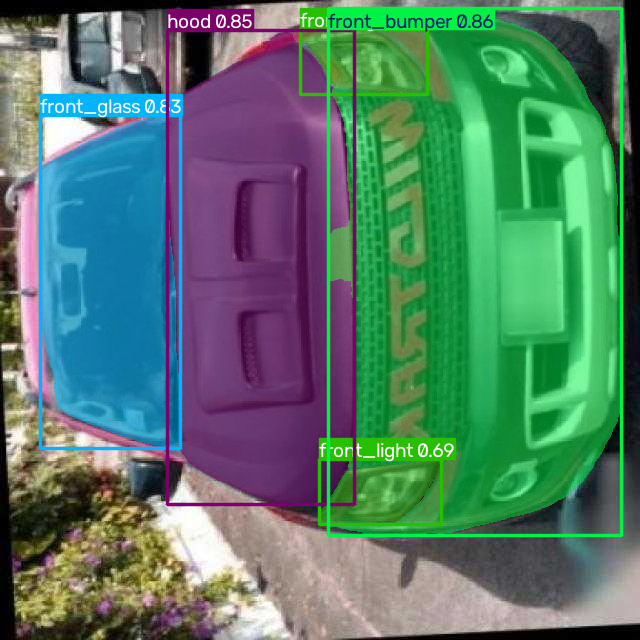

In [ ]:
import os, random

val_img_dir = '/content/datasets/carparts-seg/images/val'
sample_img = random.choice(os.listdir(val_img_dir))
sample_path = os.path.join(val_img_dir, sample_img)

results = trained_model(sample_path)
results[0].show()

#Copy Final Weights to Drive

In [ ]:
import shutil

drive_runs_dest = f'{PROJECT_ROOT}/models/parts/runs/parts_segmentation'
os.makedirs(os.path.dirname(drive_runs_dest), exist_ok=True)
if os.path.isdir(drive_runs_dest):
    shutil.rmtree(drive_runs_dest)

shutil.copytree('/content/runs/parts_segmentation', drive_runs_dest)

final_parts_model_path = f'{PROJECT_ROOT}/models/parts/best.pt'
shutil.copy(f'{drive_runs_dest}/weights/best.pt', final_parts_model_path)

print('Parts model saved at:', final_parts_model_path)
print('\nClass names for this model:')
print(trained_model.names)

Parts model saved at: /content/drive/MyDrive/AI ML/Projects//models/parts/best.pt

Class names for this model:
{0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}
